<a href="https://colab.research.google.com/github/ICS2303/Clasificador/blob/main/TallerFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy scikit-learn matplotlib seaborn streamlit pyngrok joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 67.4 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [3]:
num_students = 1000

# Generate independent variables
data = {
    'edad': np.random.randint(18, 25, num_students), # Age between 18 and 24
    'promedio': np.random.uniform(50, 100, num_students), # GPA between 50 and 100
    'asistencia': np.random.choice([0, 1], num_students, p=[0.15, 0.85]), # 85% good attendance
    'horas_estudio': np.random.normal(loc=15, scale=5, size=num_students).clip(0, 40), # Study hours, min 0, max 40
    'uso_plataforma': np.random.choice([0, 1], num_students, p=[0.2, 0.8]), # 80% use platform
    'materias_perdidas': np.random.randint(0, 4, num_students), # 0 to 3 failed courses
    'nivel_socioeconomico': np.random.choice([0, 1], num_students, p=[0.4, 0.6]), # 40% low SES (0), 60% high SES (1)
    'trabaja': np.random.choice([0, 1], num_students, p=[0.6, 0.4]), # 40% work
    'acceso_internet': np.random.choice([0, 1], num_students, p=[0.05, 0.95]) # 95% have internet access
}

df = pd.DataFrame(data)

# Normalize some continuous variables for a more stable logistic model
df['promedio_normalized'] = (df['promedio'] - df['promedio'].min()) / (df['promedio'].max() - df['promedio'].min())
df['horas_estudio_normalized'] = (df['horas_estudio'] - df['horas_estudio'].min()) / (df['horas_estudio'].max() - df['horas_estudio'].min())

# Define weights for the 'deserta' (dropout) variable, influencing its probability
# Negative weights mean lower values decrease dropout probability, positive weights increase it
weights = {
    'promedio_normalized': -3.0,  # High GPA strongly reduces dropout
    'asistencia': -1.5,           # Good attendance reduces dropout
    'horas_estudio_normalized': -1.0, # More study hours reduce dropout
    'uso_plataforma': -0.8,        # Using platform reduces dropout
    'materias_perdidas': 2.5,     # Failed courses strongly increase dropout
    'nivel_socioeconomico': -1.2, # Higher SES (1) reduces dropout
    'trabaja': 1.0,               # Working increases dropout
    'acceso_internet': -1.0       # Internet access reduces dropout
}

bias = -1.0 # Base dropout propensity

# Calculate the linear combination for logistic regression
propensity = bias \
             + df['promedio_normalized'] * weights['promedio_normalized'] \
             + df['asistencia'] * weights['asistencia'] \
             + df['horas_estudio_normalized'] * weights['horas_estudio_normalized'] \
             + df['uso_plataforma'] * weights['uso_plataforma'] \
             + df['materias_perdidas'] * weights['materias_perdidas'] \
             + df['nivel_socioeconomico'] * weights['nivel_socioeconomico'] \
             + df['trabaja'] * weights['trabaja'] \
             + df['acceso_internet'] * weights['acceso_internet']

# Add some random noise to make it less deterministic
propensity += np.random.normal(0, 0.5, num_students)

# Convert propensity to dropout probability using the sigmoid function
dropout_probability = 1 / (1 + np.exp(-propensity))

# Assign 'deserta' (dropout) based on probability
df['deserta'] = (np.random.rand(num_students) < dropout_probability).astype(int)

# Drop the normalized columns if not needed for the final dataset
df = df.drop(columns=['promedio_normalized', 'horas_estudio_normalized'])

# Display the first 5 rows of the dataset
display(df.head())

# Display general information about the dataset
print(df.info())

,edad,promedio,asistencia,horas_estudio,uso_plataforma,materias_perdidas,nivel_socioeconomico,trabaja,acceso_internet,deserta
0,22,94.823412,0,20.464395,0,0,0,0,1,0
1,18,80.156000,1,10.096167,0,3,1,0,1,0
2,24,72.679556,0,16.603009,0,3,1,1,1,1
3,22,90.663667,1,18.879798,1,1,1,1,1,0
4,19,58.583100,0,21.083785,1,1,1,0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edad                  1000 non-null   int64  
 1   promedio              1000 non-null   float64
 2   asistencia            1000 non-null   int64  
 3   horas_estudio         1000 non-null   float64
 4   uso_plataforma        1000 non-null   int64  
 5   materias_perdidas     1000 non-null   int64  
 6   nivel_socioeconomico  1000 non-null   int64  
 7   trabaja               1000 non-null   int64  
 8   acceso_internet       1000 non-null   int64  
 9   deserta               1000 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 78.3 KB
None


### 1. Descriptive Statistics
Let's start by looking at the descriptive statistics of our synthetic dataset using `df.describe()`.

In [4]:
display(df.describe())

,edad,promedio,asistencia,horas_estudio,uso_plataforma,materias_perdidas,nivel_socioeconomico,trabaja,acceso_internet,deserta
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,20.931000,75.282015,0.832000,15.166357,0.776000,1.46500,0.58400,0.368000,0.946000,0.278000
std,1.992538,14.428887,0.374053,5.071794,0.417131,1.11176,0.49314,0.482503,0.226131,0.448238
min,18.000000,50.005363,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
25%,19.000000,62.468901,1.000000,11.861520,1.000000,0.00000,0.00000,0.000000,1.000000,0.000000
50%,21.000000,75.827116,1.000000,15.324101,1.000000,1.00000,1.00000,0.000000,1.000000,0.000000
75%,23.000000,87.643190,1.000000,18.549794,1.000000,2.00000,1.00000,1.000000,1.000000,1.000000
max,24.000000,99.992678,1.000000,30.521655,1.000000,3.00000,1.00000,1.000000,1.000000,1.000000


### 2. Check for Missing Values
It's important to know if there are any missing values in our dataset.

In [5]:
print(df.isnull().sum())

edad                    0
promedio                0
asistencia              0
horas_estudio           0
uso_plataforma          0
materias_perdidas       0
nivel_socioeconomico    0
trabaja                 0
acceso_internet         0
deserta                 0
dtype: int64


### 3. Histograms for Numerical Features
Let's visualize the distribution of each numerical feature using histograms.

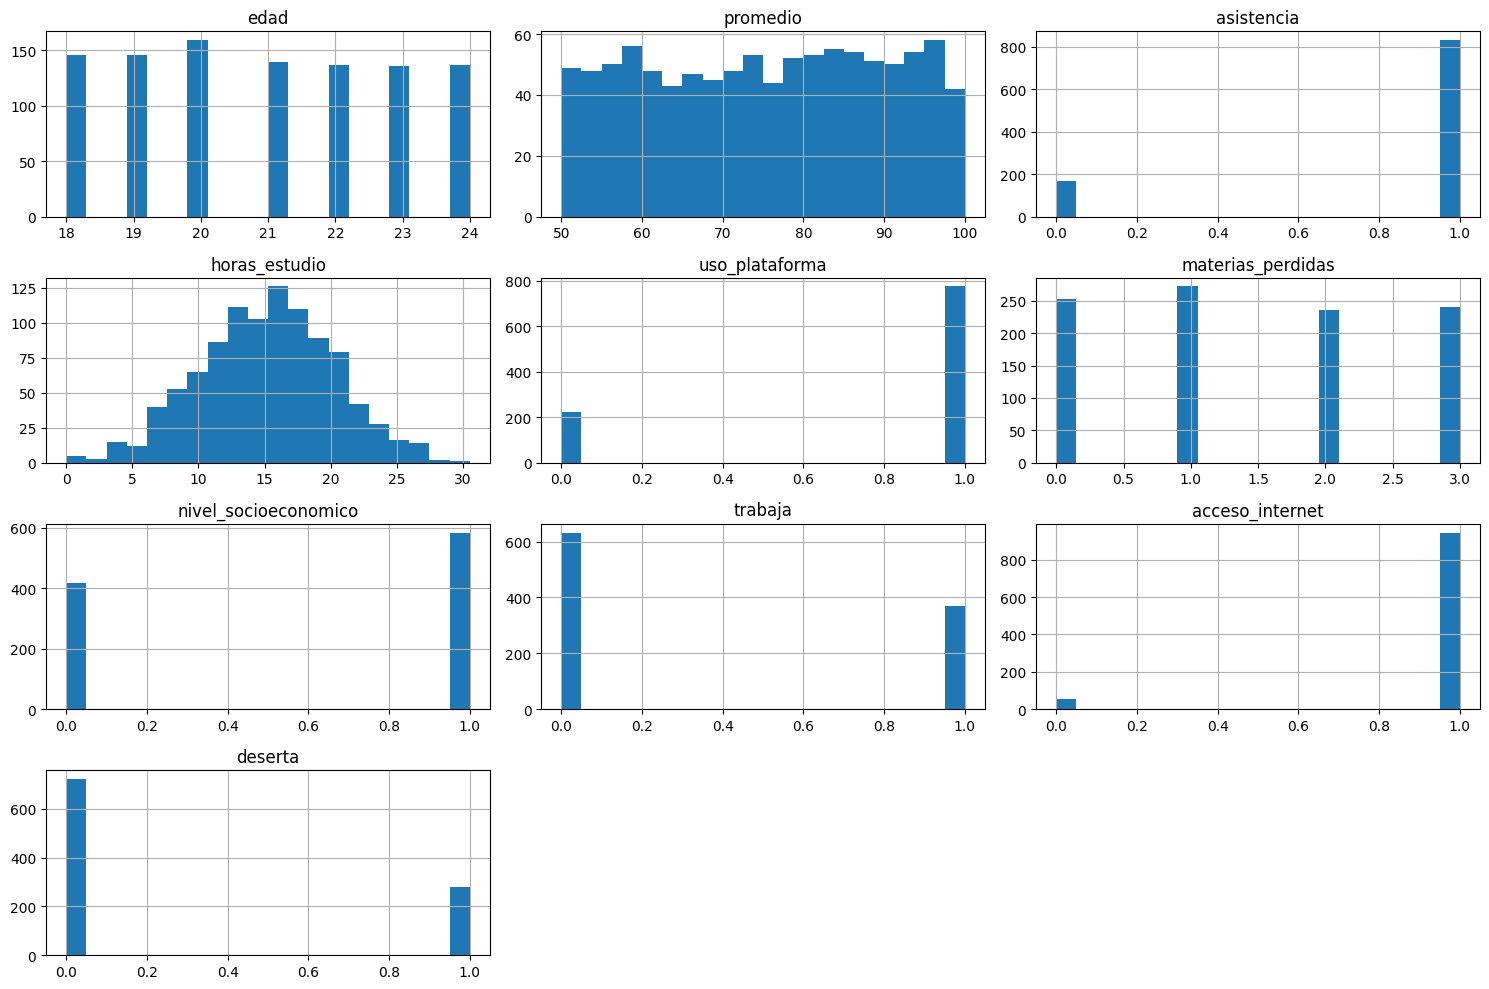

In [6]:
df.hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.show()

### 4. Correlation Matrix and Heatmap
Understanding the correlation between variables can reveal important relationships. We'll calculate the correlation matrix and visualize it with a heatmap.

,edad,promedio,asistencia,horas_estudio,uso_plataforma,materias_perdidas,nivel_socioeconomico,trabaja,acceso_internet,deserta
edad,1.000000,0.025491,-0.018255,-0.028662,-0.018615,-0.012614,-0.040448,0.022273,0.051706,-0.019970
promedio,0.025491,1.000000,0.039530,-0.039613,-0.006141,-0.002487,-0.033754,0.015802,0.002611,-0.193482
asistencia,-0.018255,0.039530,1.000000,-0.001943,0.015192,-0.014154,0.011461,0.021209,-0.024521,-0.133113
horas_estudio,-0.028662,-0.039613,-0.001943,1.000000,0.019431,0.012787,0.029114,-0.007076,0.021626,0.002959
uso_plataforma,-0.018615,-0.006141,0.015192,0.019431,1.000000,0.002504,0.038034,0.031990,-0.022243,-0.041373
materias_perdidas,-0.012614,-0.002487,-0.014154,0.012787,0.002504,1.000000,-0.019280,0.007240,0.032291,0.622155
nivel_socioeconomico,-0.040448,-0.033754,0.011461,0.029114,0.038034,-0.019280,1.000000,0.000370,-0.022118,-0.110278
trabaja,0.022273,0.015802,0.021209,-0.007076,0.031990,0.007240,0.000370,1.000000,0.053872,0.137444
acceso_internet,0.051706,0.002611,-0.024521,0.021626,-0.022243,0.032291,-0.022118,0.053872,1.000000,-0.029509
deserta,-0.019970,-0.193482,-0.133113,0.002959,-0.041373,0.622155,-0.110278,0.137444,-0.029509,1.000000


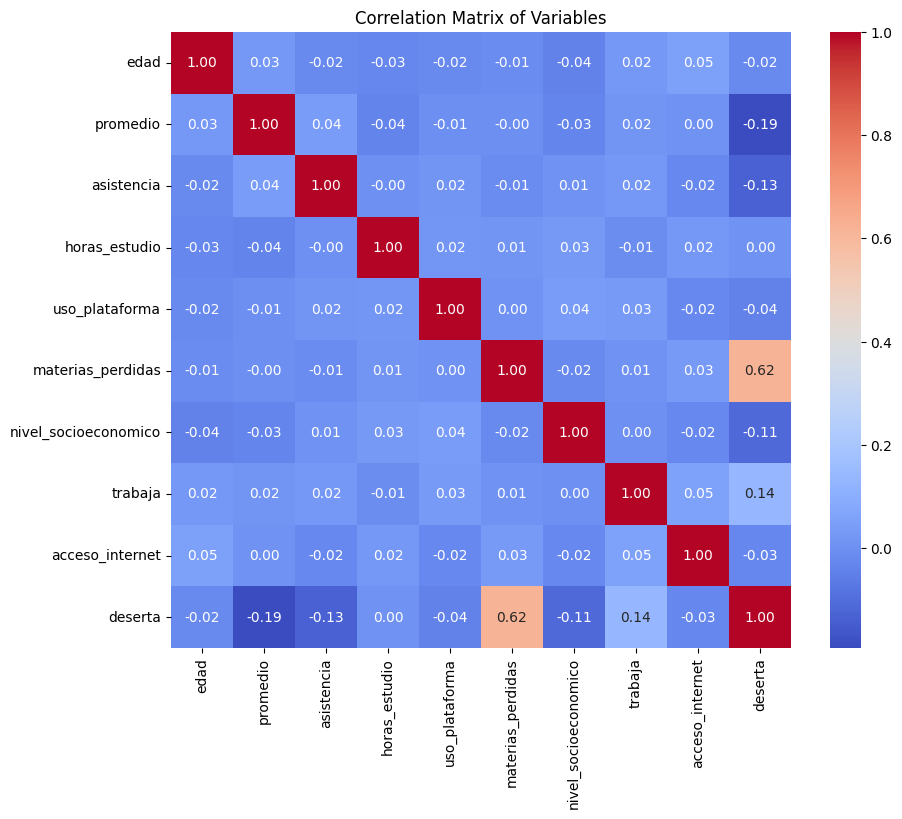

In [7]:
correlation_matrix = df.corr()
display(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Variables')
plt.show()

### 5. Distribution of 'deserta' Variable
Finally, let's look at the distribution of our target variable, 'deserta' (dropout status).

/tmp/ipykernel_3100/3287439009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='deserta', data=df, palette='viridis')


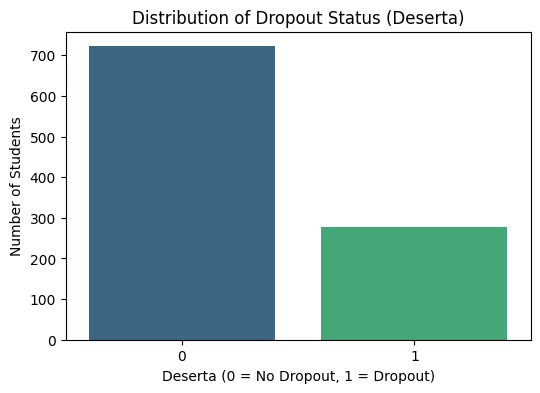

,proportion
deserta,
0,0.722
1,0.278


In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='deserta', data=df, palette='viridis')
plt.title('Distribution of Dropout Status (Deserta)')
plt.xlabel('Deserta (0 = No Dropout, 1 = Dropout)')
plt.ylabel('Number of Students')
plt.show()

display(df['deserta'].value_counts(normalize=True))

### 6. Preparing Data for Model Training
We need to separate our features (X) from our target variable (y) and then split the data into training and testing sets.

In [13]:
# Separate features (X) and target (y)
X = df.drop('deserta', axis=1)
y = df['deserta']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (700, 9)
X_test shape: (300, 9)
y_train shape: (700,)
y_test shape: (300,)


### 7. Training a Logistic Regression Model
Now, let's train a Logistic Regression model on our training data.

In [14]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets and binary classification
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### 8. Evaluating the Model
We'll evaluate the model's performance on the test set using accuracy and a classification report.

In [15]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

Model Accuracy: 0.8767

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       217
           1       0.77      0.80      0.78        83

    accuracy                           0.88       300
   macro avg       0.84      0.85      0.85       300
weighted avg       0.88      0.88      0.88       300



### 9. Model Serialization
Finally, we'll save our trained model using `joblib` so it can be reused later without retraining.

In [12]:
# Save the trained model
joblib.dump(model, 'logistic_regression_model.pkl')

print("Model saved as 'logistic_regression_model.pkl'")

Model saved as 'logistic_regression_model.pkl'


### 10. Training a RandomForestClassifier Model
Now, let's train a RandomForestClassifier model on our training data and make predictions.

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully!")

RandomForestClassifier model trained successfully!


In [17]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

print("Predictions made successfully!")
print("First 5 predictions:")
display(y_pred_rf[:5])

Predictions made successfully!
First 5 predictions:


array([1, 0, 1, 0, 0])

### 11. Evaluating the RandomForestClassifier Model
Now, let's evaluate the performance of our `RandomForestClassifier` model on the test set.

In [18]:
# Evaluate the RandomForestClassifier model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"RandomForestClassifier Model Accuracy: {accuracy_rf:.4f}")
print("\nRandomForestClassifier Classification Report:")
print(report_rf)

RandomForestClassifier Model Accuracy: 0.8700

RandomForestClassifier Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       217
           1       0.80      0.71      0.75        83

    accuracy                           0.87       300
   macro avg       0.85      0.82      0.83       300
weighted avg       0.87      0.87      0.87       300



### 12. Model Serialization for RandomForestClassifier
Let's save our trained RandomForestClassifier model using `joblib`.

In [19]:
# Save the trained RandomForestClassifier model
joblib.dump(rf_model, 'random_forest_model.pkl')

print("RandomForestClassifier model saved as 'random_forest_model.pkl'")

RandomForestClassifier model saved as 'random_forest_model.pkl'


### 13. Comprehensive Model Evaluation Function
Let's create a reusable function to evaluate our classification models using various metrics and visualize the confusion matrix.

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_classifier_model(y_true, y_pred, model_name="Model"):
    """
    Evaluates a classification model and prints key metrics along with a confusion matrix.

    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        model_name (str): Name of the model for display purposes.
    """
    accuracy = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(report)

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f"Confusion Matrix for {model_name}")
    plt.show()
    print("\n")

### 14. Re-evaluating Logistic Regression Model
Using our new evaluation function to get a complete picture of the Logistic Regression model's performance.

--- Logistic Regression Evaluation ---
Accuracy: 0.8767

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       217
           1       0.77      0.80      0.78        83

    accuracy                           0.88       300
   macro avg       0.84      0.85      0.85       300
weighted avg       0.88      0.88      0.88       300



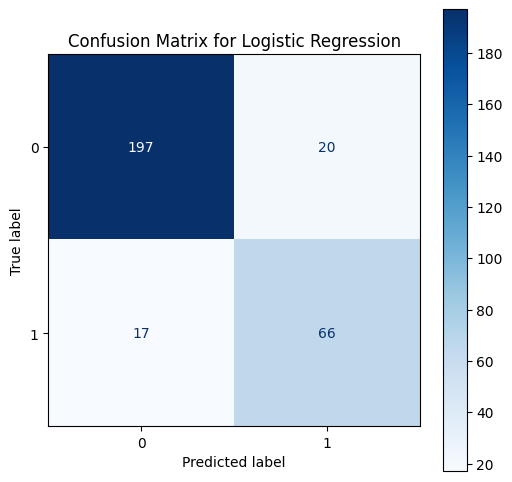

In [21]:
# Evaluate Logistic Regression Model
evaluate_classifier_model(y_test, y_pred, model_name="Logistic Regression")

### 15. Re-evaluating RandomForestClassifier Model
Now, let's do the same for the RandomForestClassifier model.

--- RandomForestClassifier Evaluation ---
Accuracy: 0.8700

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       217
           1       0.80      0.71      0.75        83

    accuracy                           0.87       300
   macro avg       0.85      0.82      0.83       300
weighted avg       0.87      0.87      0.87       300



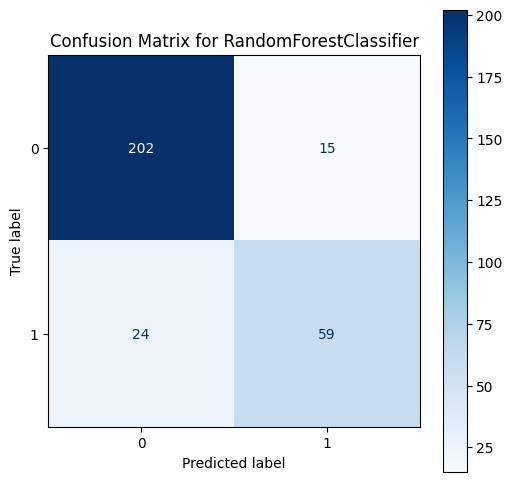

In [22]:
# Evaluate RandomForestClassifier Model
evaluate_classifier_model(y_test, y_pred_rf, model_name="RandomForestClassifier")

### 16. Analyzing Feature Importance for Logistic Regression
For Logistic Regression, we can look at the coefficients to understand feature importance.

In [23]:
feature_importance_lr = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
feature_importance_lr['Absolute_Coefficient'] = abs(feature_importance_lr['Coefficient'])
feature_importance_lr = feature_importance_lr.sort_values(by='Absolute_Coefficient', ascending=False)

print("Logistic Regression Feature Importance (by absolute coefficient value):")
display(feature_importance_lr)

Logistic Regression Feature Importance (by absolute coefficient value):


,Feature,Coefficient,Absolute_Coefficient
5,materias_perdidas,2.383207,2.383207
2,asistencia,-1.501487,1.501487
7,trabaja,1.460231,1.460231
8,acceso_internet,-1.076836,1.076836
6,nivel_socioeconomico,-0.902908,0.902908
4,uso_plataforma,-0.417114,0.417114
1,promedio,-0.053563,0.053563
0,edad,0.030490,0.030490
3,horas_estudio,-0.005815,0.005815


### 17. Analyzing Feature Importance for RandomForestClassifier
Random Forest models provide a direct measure of feature importance.

RandomForestClassifier Feature Importance:


,Feature,Importance
5,materias_perdidas,0.415923
1,promedio,0.205191
3,horas_estudio,0.162372
0,edad,0.081277
7,trabaja,0.041297
6,nivel_socioeconomico,0.030081
2,asistencia,0.026399
4,uso_plataforma,0.025675
8,acceso_internet,0.011784


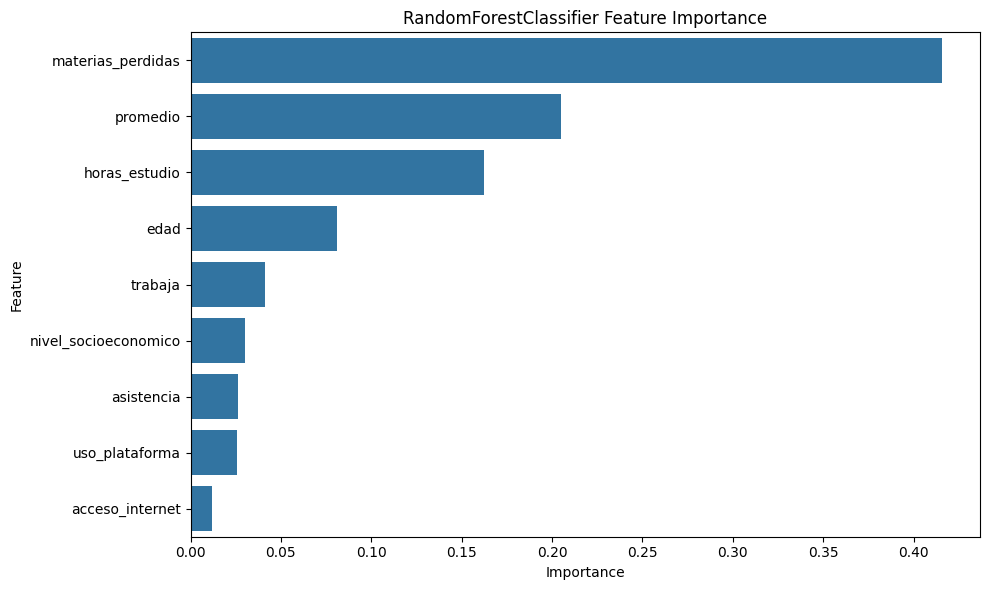

In [24]:
feature_importance_rf = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

print("RandomForestClassifier Feature Importance:")
display(feature_importance_rf)

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf)
plt.title('RandomForestClassifier Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 18. Guardar y Cargar Modelos Entrenados con `joblib`
A continuación, se muestra cómo guardar los modelos entrenados en archivos `.pkl` y cómo cargarlos de nuevo para su uso.

In [25]:
# Guardar el modelo de Regresión Logística
joblib.dump(model, 'modelo_desercion_lr.pkl')
print("Modelo de Regresión Logística guardado como 'modelo_desercion_lr.pkl'")

# Cargar el modelo de Regresión Logística
loaded_lr_model = joblib.load('modelo_desercion_lr.pkl')
print("Modelo de Regresión Logística cargado exitosamente.")

# Puedes verificar que el modelo cargado funciona haciendo una predicción
# print("Predicción con modelo cargado (Regresión Logística):")
# display(loaded_lr_model.predict(X_test[:5]))

Modelo de Regresión Logística guardado como 'modelo_desercion_lr.pkl'
Modelo de Regresión Logística cargado exitosamente.


In [26]:
# Guardar el modelo RandomForestClassifier
joblib.dump(rf_model, 'modelo_desercion_rf.pkl')
print("Modelo RandomForestClassifier guardado como 'modelo_desercion_rf.pkl'")

# Cargar el modelo RandomForestClassifier
loaded_rf_model = joblib.load('modelo_desercion_rf.pkl')
print("Modelo RandomForestClassifier cargado exitosamente.")

# Puedes verificar que el modelo cargado funciona haciendo una predicción
# print("Predicción con modelo cargado (RandomForestClassifier):")
# display(loaded_rf_model.predict(X_test[:5]))

Modelo RandomForestClassifier guardado como 'modelo_desercion_rf.pkl'
Modelo RandomForestClassifier cargado exitosamente.


### 19. Streamlit Application for Student Dropout Prediction

Now, let's create a Streamlit application to interactively predict student dropout based on user inputs. We will save the app code to a Python file and then run it using `pyngrok`.

In [27]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from pyngrok import ngrok

# Save the Streamlit app code to a file
streamlit_app_code = '''
import streamlit as st
import pandas as pd
import joblib
import numpy as np

st.set_page_config(layout="centered")

# Load the trained model
# Assuming the model is saved in the same directory as the Streamlit app or accessible path
# Using the Logistic Regression model for this application as it was favored for recall.
try:
    model = joblib.load('modelo_desercion_lr.pkl')
    st.success("Modelo de Regresión Logística cargado exitosamente!")
except FileNotFoundError:
    st.error("Error: modelo_desercion_lr.pkl no encontrado. Asegúrate de que el modelo esté guardado en la ubicación correcta.")
    st.stop() # Stop the app if model is not found

# Title of the application
st.title("🎓 Predicción de Deserción Estudiantil")
st.write("Ingresa los datos del estudiante para predecir si desertará o no.")

# Input fields for features
st.sidebar.header("Parámetros del Estudiante")

edad = st.sidebar.slider("Edad", min_value=18, max_value=25, value=20, step=1)
promedio = st.sidebar.slider("Promedio (0-100)", min_value=50.0, max_value=100.0, value=75.0, step=0.1)
asistencia = st.sidebar.selectbox("Asistencia", options=[0, 1], format_func=lambda x: "Buena (1)" if x == 1 else "Mala (0)")
horas_estudio = st.sidebar.slider("Horas de Estudio Semanales", min_value=0.0, max_value=40.0, value=15.0, step=0.5)
uso_plataforma = st.sidebar.selectbox("Uso de Plataforma Educativa", options=[0, 1], format_func=lambda x: "Sí (1)" if x == 1 else "No (0)")
materias_perdidas = st.sidebar.slider("Materias Perdidas", min_value=0, max_value=3, value=1, step=1)
nivel_socioeconomico = st.sidebar.selectbox("Nivel Socioeconómico", options=[0, 1], format_func=lambda x: "Bajo (0)" if x == 0 else "Alto (1)")
trabaja = st.sidebar.selectbox("Trabaja", options=[0, 1], format_func=lambda x: "Sí (1)" if x == 1 else "No (0)")
acceso_internet = st.sidebar.selectbox("Acceso a Internet", options=[0, 1], format_func=lambda x: "Sí (1)" if x == 1 else "No (0)")

# Create a DataFrame from inputs
input_data = pd.DataFrame([[edad, promedio, asistencia, horas_estudio, uso_plataforma, materias_perdidas, nivel_socioeconomico, trabaja, acceso_internet]],
                          columns=['edad', 'promedio', 'asistencia', 'horas_estudio', 'uso_plataforma', 'materias_perdidas', 'nivel_socioeconomico', 'trabaja', 'acceso_internet'])


st.subheader("Datos del Estudiante Ingresados:")
st.write(input_data)

# Make prediction
if st.button("Predecir Deserción"):
    if model is not None:
        prediction = model.predict(input_data)
        prediction_proba = model.predict_proba(input_data)

        st.subheader("Resultado de la Predicción:")
        if prediction[0] == 1:
            st.error(f"¡El estudiante tiene una alta probabilidad de desertar! ⚠️ (Probabilidad: {prediction_proba[0][1]:.2f})")
            st.markdown("Considera implementar intervenciones tempranas como tutorías o apoyo socioeconómico.")
        else:
            st.success(f"El estudiante tiene baja probabilidad de desertar. ✅ (Probabilidad: {prediction_proba[0][0]:.2f})")
            st.markdown("¡Excelente! El estudiante parece estar en buen camino.")

        st.markdown("--- Generado por Colab Composer ---")
    else:
        st.warning("El modelo no ha sido cargado. Por favor, verifica la ruta del archivo.")
'''

with open('streamlit_app.py', 'w') as f:
    f.write(streamlit_app_code)

print("Streamlit app code saved to 'streamlit_app.py'")

Streamlit app code saved to 'streamlit_app.py'


In [30]:
# Run the Streamlit app directly (without ngrok as requested)
!streamlit run streamlit_app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false



2026-05-12 21:32:06.830 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.232.200.96:8501

  Stopping...
Exception in callback Loop._read_from_self
handle: <Handle Loop._read_from_self>
Traceback (most recent call last):
  File "uvloop/cbhandles.pyx", line 66, in uvloop.loop.Handle._run
  File "uvloop/loop.pyx", line 399, in uvloop.loop.Loop._read_from_self
  File "uvloop/loop.pyx", line 404, in uvloop.loop.Loop._invoke_signals
  File "uvloop/loop.pyx", line 379, in uvloop.loop.Loop._ceval_process_signals
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/server/server.py", line 120, in stop
    cli_util.print_to_cli("  Stopping...", fg="blue")
  File "/usr/local/lib/python3.12/dist-packages/streamlit/cli_util

### 20. Generating and Running the Streamlit Application (`app.py`)

In [31]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Streamlit app code content
streamlit_app_code = '''
import streamlit as st
import pandas as pd
import joblib
import numpy as np

st.set_page_config(layout="centered")

# Load the trained model
# Using the Logistic Regression model for this application as it was favored for recall.
try:
    # Ensure the model file name matches exactly what was saved earlier
    model = joblib.load('modelo_desercion_lr.pkl')
    st.success("Modelo de Regresión Logística cargado exitosamente!")
except FileNotFoundError:
    st.error("Error: modelo_desercion_lr.pkl no encontrado. Asegúrate de que el modelo esté guardado en la ubicación correcta.")
    st.stop() # Stop the app if model is not found

# Title of the application
st.title("🎓 Predicción de Deserción Estudiantil")
st.write("Ingresa los datos del estudiante para predecir si desertará o no.")

# Input fields for features
st.sidebar.header("Parámetros del Estudiante")

edad = st.sidebar.slider("Edad", min_value=18, max_value=25, value=20, step=1)
promedio = st.sidebar.slider("Promedio (0-100)", min_value=50.0, max_value=100.0, value=75.0, step=0.1)
asistencia = st.sidebar.selectbox("Asistencia", options=[0, 1], format_func=lambda x: "Buena (1)" if x == 1 else "Mala (0)")
horas_estudio = st.sidebar.slider("Horas de Estudio Semanales", min_value=0.0, max_value=40.0, value=15.0, step=0.5)
uso_plataforma = st.sidebar.selectbox("Uso de Plataforma Educativa", options=[0, 1], format_func=lambda x: "Sí (1)" if x == 1 else "No (0)")
materias_perdidas = st.sidebar.slider("Materias Perdidas", min_value=0, max_value=3, value=1, step=1)
nivel_socioeconomico = st.sidebar.selectbox("Nivel Socioeconómico", options=[0, 1], format_func=lambda x: "Bajo (0)" if x == 0 else "Alto (1)")
trabaja = st.sidebar.selectbox("Trabaja", options=[0, 1], format_func=lambda x: "Sí (1)" if x == 1 else "No (0)")
acceso_internet = st.sidebar.selectbox("Acceso a Internet", options=[0, 1], format_func=lambda x: "Sí (1)" if x == 1 else "No (0)")

# Create a DataFrame from inputs
input_data = pd.DataFrame([[edad, promedio, asistencia, horas_estudio, uso_plataforma, materias_perdidas, nivel_socioeconomico, trabaja, acceso_internet]],
                          columns=['edad', 'promedio', 'asistencia', 'horas_estudio', 'uso_plataforma', 'materias_perdidas', 'nivel_socioeconomico', 'trabaja', 'acceso_internet'])


st.subheader("Datos del Estudiante Ingresados:")
st.write(input_data)

# Make prediction
if st.button("Predecir Deserción"):
    if model is not None:
        prediction = model.predict(input_data)
        prediction_proba = model.predict_proba(input_data)

        st.subheader("Resultado de la Predicción:")
        if prediction[0] == 1:
            st.error(f"¡El estudiante tiene una alta probabilidad de desertar! ⚠️ (Probabilidad: {prediction_proba[0][1]:.2f})")
            st.markdown("Considera implementar intervenciones tempranas como tutorías o apoyo socioeconómico.")
        else:
            st.success(f"El estudiante tiene baja probabilidad de desertar. ✅ (Probabilidad: {prediction_proba[0][0]:.2f})")
            st.markdown("¡Excelente! El estudiante parece estar en buen camino.")

        st.markdown("--- Generado por Colab Composer ---")
    else:
        st.warning("El modelo no ha sido cargado. Por favor, verifica la ruta del archivo.")
'''

with open('app.py', 'w') as f:
    f.write(streamlit_app_code)

print("Streamlit app code saved to 'app.py'")

Streamlit app code saved to 'app.py'


In [32]:
# Run the Streamlit app
!streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false



2026-05-12 21:34:44.161 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.232.200.96:8501

  Stopping...
  Stopping...
  Stopping...
  Stopping...


### 21. `requirements.txt` file

In [33]:
%%writefile requirements.txt
pandas
numpy
scikit-learn
matplotlib
seaborn
streamlit
joblib
pyngrok # Though not used in the final app.py, it was part of the initial setup.


Writing requirements.txt


In [34]:
!pip install streamlit pyngrok joblib

In [35]:
from pyngrok import ngrok
ngrok.set_auth_token("3DdpRwqiV82mMx5SFc5y0lX4Alh_3y8FAKojoQmDHkR3S76oo")

In [ ]:
from pyngrok import ngrok

# Set the ngrok authentication token
# The user provided a token in cell BNyH8xzfJSy-, so I'll use that.
ngrok.set_auth_token("3DdpRwqiV82mMx5SFc5y0lX4Alh_3y8FAKojoQmDHkR3S76oo")

# Kill any existing ngrok tunnels
ngrok.kill()

# Open a ngrok tunnel to the Streamlit app port (default 8501)
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

# Run the Streamlit app
!streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false

Streamlit App URL: NgrokTunnel: "https://pounce-emerald-chapter.ngrok-free.dev" -> "http://localhost:8501"


2026-05-12 21:47:04.837 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.232.200.96:8501

